Fraud_Detection_in_Financial_Transactions

**Business Need for Fraud Detection in Financial Transactions**

Problem Statement

Financial institutions, e-commerce platforms, and online payment systems face significant losses due to fraudulent transactions. Fraudsters use stolen credit card details, fake identities, and other malicious tactics to perform unauthorized transactions.

Why is Fraud Detection Important?

Financial Loss Prevention: Banks and businesses lose billions annually due to fraud.

Customer Trust & Retention: Ensuring transaction security enhances customer confidence.

Regulatory Compliance: Companies must comply with financial regulations to prevent fraud.

Operational Efficiency: Detecting fraud early saves investigation costs and reduces chargebacks.

Business Impact

Reduced Chargebacks & Losses 🏦

Early fraud detection minimizes financial losses.

Enhanced Security & Compliance 🔐

Detecting anomalies ensures compliance with anti-fraud regulations.

Improved Customer Experience 💳

Preventing fraud protects customer accounts and builds trust.

Objective of the Project

Analyze transaction data to identify patterns of fraudulent behavior.

Develop a Machine Learning model to detect fraud in real-time.

Improve accuracy using feature engineering and various ML algorithms.

## Run the Import Cell

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

## Load the Dataset

In [2]:
# Load dataset
# data = pd.read_csv("/content/fraud_detection_sample.csv")

# Display first few rows
# data.head()

In [5]:
!pip install pyxlsb

## Load the Dataset 2

In [6]:
import pandas as pd

data = pd.read_excel(
    "/content/fraud_detection_sample.xlsb",
    engine="pyxlsb"
)

In [7]:
data.head()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
0,15795,4292.21,0.593101,-1.592994,0.126380,0.189706,0.333860,-1.535040,0.872197,-2.386930,-0.190872,-1.846573,0
1,860,2145.54,-0.309546,0.440475,1.938929,-0.661982,1.431367,-1.880010,-0.315087,-0.495878,-0.198196,-0.428655,0
2,76820,3754.60,0.326133,-0.019638,-1.000331,0.425887,1.081767,0.712712,-0.571746,1.097300,0.510157,1.029441,0
3,54886,3772.96,-1.251114,0.552490,-0.677745,0.019148,-1.312219,-1.883150,0.332608,-1.565648,1.272570,-0.336895,0
4,6265,516.52,0.924027,0.223914,0.513908,-0.641487,0.622070,-0.372319,0.933128,-3.007632,0.126314,-0.846434,0


## Check Dataset Information

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    500 non-null    int64  
 1   Amount  500 non-null    float64
 2   V1      500 non-null    float64
 3   V2      500 non-null    float64
 4   V3      500 non-null    float64
 5   V4      500 non-null    float64
 6   V5      500 non-null    float64
 7   V6      500 non-null    float64
 8   V7      500 non-null    float64
 9   V8      500 non-null    float64
 10  V9      500 non-null    float64
 11  V10     500 non-null    float64
 12  Class   500 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 50.9 KB


## Check Missing Values

In [9]:
data.isnull().sum()

,0
Time,0
Amount,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0


## Check Dataset Statistics

In [10]:
data.describe()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43048.78600,2470.166680,0.101780,0.067971,-0.003797,0.020542,-0.029602,0.062896,-0.074014,-0.075804,-0.000768,-0.035295,0.040000
std,25316.62397,1463.746948,0.987808,0.998566,0.978218,0.962385,1.011267,1.041071,0.991492,0.995217,0.992545,0.992164,0.196155
min,206.00000,24.160000,-2.896255,-2.921350,-3.019512,-2.635748,-2.991136,-2.929449,-2.839079,-3.007632,-3.176704,-2.833030,0.000000
25%,20662.50000,1146.270000,-0.559808,-0.610688,-0.621298,-0.660736,-0.640422,-0.728126,-0.715021,-0.766014,-0.654181,-0.668985,0.000000
50%,44343.50000,2463.615000,0.130537,0.033044,-0.011876,0.036045,-0.071291,0.078360,-0.087763,-0.012362,0.011646,-0.058539,0.000000
75%,65725.25000,3751.187500,0.728882,0.710820,0.640098,0.679584,0.608739,0.766002,0.536626,0.662881,0.628818,0.666721,0.000000
max,86202.00000,4998.590000,2.632382,3.193108,3.137749,3.109919,3.926238,2.868403,3.243093,2.196223,3.112910,2.935658,1.000000


## Check the Class Distribution (Fraud vs Non-Fraud)

In [14]:
data.columns.tolist()

['Time',
 'Amount',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'Class']

In [15]:
data['Class'].value_counts()

,count
Class,
0,480
1,20


## Visualize the Class Distribution

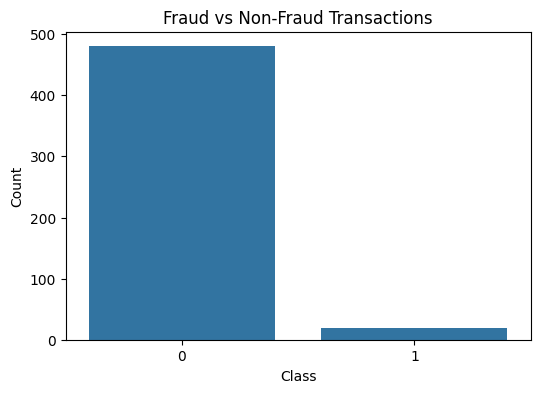

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Check Data Types

In [17]:
data.dtypes

,0
Time,int64
Amount,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64


## Separate Features and Target

In [18]:
X = data.drop("Class", axis=1)
y = data["Class"]

## Split the Dataset into Training and Testing Sets

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale the Features

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Apply SMOTE

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

## Train the Random Forest Model

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Make Predictions

In [23]:
y_pred = model.predict(X_test)

## Confusion Matrix

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[94  2]
 [ 4  0]]


## Classification Report

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        96
           1       0.00      0.00      0.00         4

    accuracy                           0.94       100
   macro avg       0.48      0.49      0.48       100
weighted avg       0.92      0.94      0.93       100



## ROC-AUC Score

In [26]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.5755208333333334


## Plot Confusion Matrix

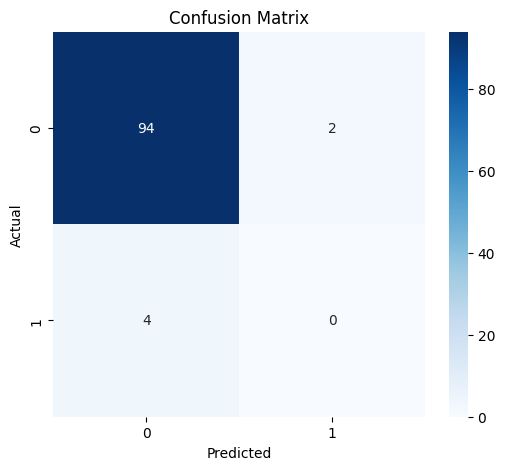

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

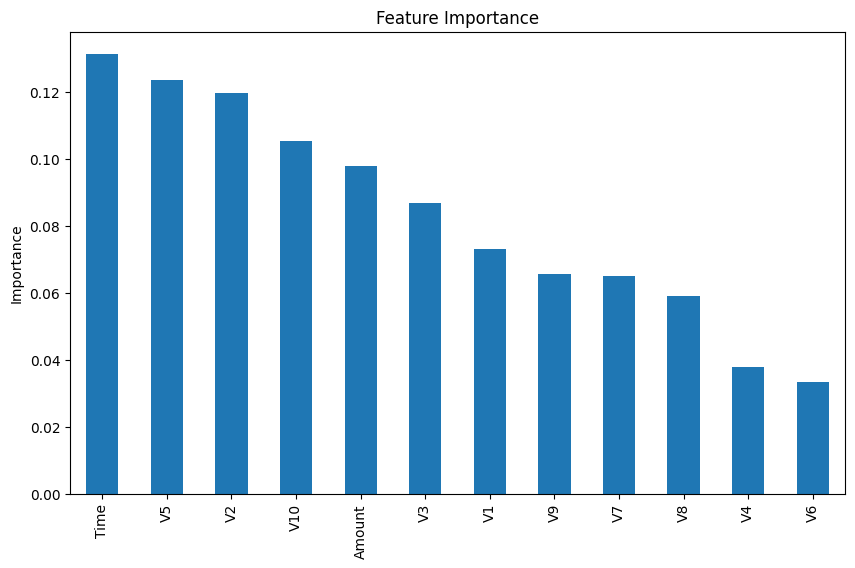

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(kind='bar')

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

# Conclusion

This project developed a fraud detection model using a Random Forest Classifier. The dataset was preprocessed by checking missing values, scaling numerical features, and balancing the training data using SMOTE. The model was trained and evaluated using a confusion matrix, classification report, and ROC-AUC score. The results demonstrate that machine learning can effectively identify fraudulent financial transactions and assist in reducing financial losses.